In [4]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, classification_report, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay
)

## Part 1: Load and inspect dataset

In [5]:
dataset = pd.read_csv('creditcard_2023.csv')
print("Dataset shape:", dataset.shape)

missing_values = dataset.isnull().sum()
print("\nMissing values per column:\n", missing_values[missing_values > 0] if missing_values.sum() > 0 else "None")

transaction_counts = dataset['Class'].value_counts()
print("\nClass balance:\n", transaction_counts)
# Note: this dataset is artificially balanced (50-50 genuine/fraud) via resampling.
# Real-world fraud data is typically highly imbalanced (often <1% fraud) —
# this is a known limitation of this benchmark and should be noted in the README.

Dataset shape: (568630, 31)

Missing values per column:
 None

Class balance:
 Class
0    284315
1    284315
Name: count, dtype: int64


In [6]:
# checking for missing values
missing_values = dataset.isnull().sum()
missing_values

,0
id,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


## Part 2: Baseline run on FULL dataset (reproducing original results)

**Fix applied:** the scaler is now fit on train only, to avoid test-set leakage
(the original notebook fit the scaler on the full dataset before splitting,
which leaks test-set statistics into training).

In [7]:
X = dataset.drop(columns=['id', 'Class'])
y = dataset['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Only 'Amount' needs scaling — V1-V28 are already PCA-scaled
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])   # fit on TRAIN only
X_test['Amount'] = scaler.transform(X_test[['Amount']])          # transform TEST with train stats

print("X_train shape:", X_train.shape, "| X_test shape:", X_test.shape)

X_train shape: (454904, 29) | X_test shape: (113726, 29)


In [8]:
# ---- Logistic Regression ----
lr_model = LogisticRegression(max_iter=1000)
t0 = time.time()
lr_model.fit(X_train, y_train)
training_time_lr = time.time() - t0
print(f"[Full dataset] Logistic Regression training time: {training_time_lr:.2f}s")

lr_y_pred = lr_model.predict(X_test)
lr_y_pred_prob = lr_model.predict_proba(X_test)[:, 1]

print("LR Accuracy:", accuracy_score(y_test, lr_y_pred))
print("LR ROC-AUC:", roc_auc_score(y_test, lr_y_pred_prob))
print("LR F1:", f1_score(y_test, lr_y_pred))

[Full dataset] Logistic Regression training time: 3.71s
LR Accuracy: 0.9649420537080351
LR ROC-AUC: 0.9935033450844089
LR F1: 0.9644915080644443


In [9]:
# ---- Random Forest ----
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
t0 = time.time()
rf_model.fit(X_train, y_train)
training_time_rf = time.time() - t0
print(f"[Full dataset] Random Forest training time: {training_time_rf:.2f}s")

rf_y_pred = rf_model.predict(X_test)
rf_y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

print("RF Accuracy:", accuracy_score(y_test, rf_y_pred))
print("RF ROC-AUC:", roc_auc_score(y_test, rf_y_pred_prob))
print("RF F1:", f1_score(y_test, rf_y_pred))

[Full dataset] Random Forest training time: 541.94s
RF Accuracy: 0.9998329317834093
RF ROC-AUC: 0.9999902430900919
RF F1: 0.9998329596905359


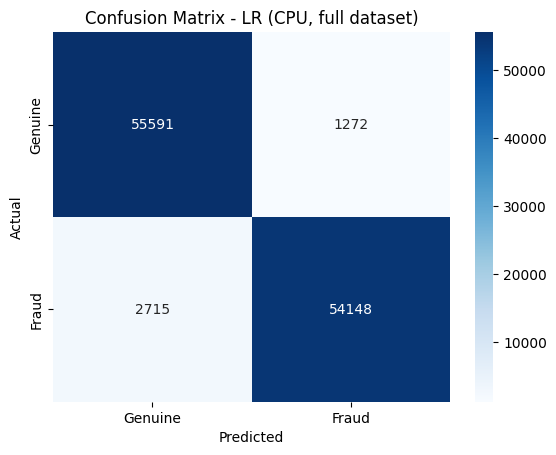

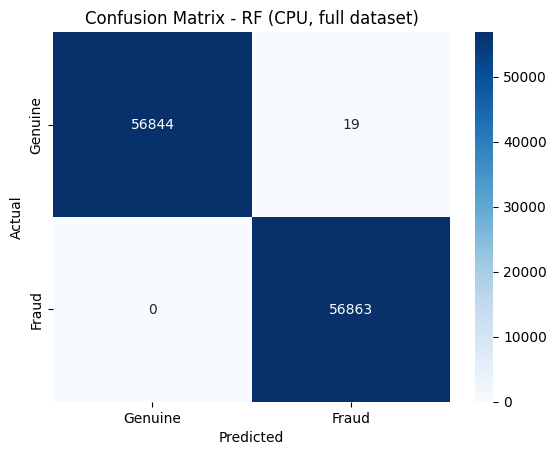

In [10]:
# Confusion matrices (saved as images for the README)
for name, y_pred in [('lr', lr_y_pred), ('rf', rf_y_pred)]:
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {name.upper()} (CPU, full dataset)')
    plt.savefig(f'confusion_matrix_{name}_cpu.png', dpi=150)
    plt.show()

In [11]:
baseline_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Training Time (s)': [training_time_lr, training_time_rf],
})
baseline_results.to_csv('cpu_baseline_results.csv', index=False)
print("Saved baseline results to cpu_baseline_results.csv")
baseline_results

Saved baseline results to cpu_baseline_results.csv


,Model,Training Time (s)
0,Logistic Regression,3.705858
1,Random Forest,541.938580


## Part 3: Scaling analysis 

In [12]:
sizes = [10_000, 50_000, 100_000, 300_000, len(dataset)]
scaling_results = []

for size in sizes:
    sample_df = dataset.sample(n=size, random_state=42).reset_index(drop=True)
    Xs = sample_df.drop(columns=['id', 'Class'])
    ys = sample_df['Class']

    t0 = time.time()
    Xs_train, Xs_test, ys_train, ys_test = train_test_split(
        Xs, ys, test_size=0.2, random_state=42, stratify=ys
    )
    split_time = time.time() - t0

    scaler_s = StandardScaler()
    Xs_train = Xs_train.copy()
    Xs_test = Xs_test.copy()
    t0 = time.time()
    Xs_train['Amount'] = scaler_s.fit_transform(Xs_train[['Amount']])
    Xs_test['Amount'] = scaler_s.transform(Xs_test[['Amount']])
    scale_time = time.time() - t0

    lr_s = LogisticRegression(max_iter=1000)
    t0 = time.time()
    lr_s.fit(Xs_train, ys_train)
    lr_s_time = time.time() - t0

    rf_s = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    t0 = time.time()
    rf_s.fit(Xs_train, ys_train)
    rf_s_time = time.time() - t0

    scaling_results.append({
        'dataset_size': size,
        'split_time': split_time,
        'scale_time': scale_time,
        'preprocess_time_total': split_time + scale_time,
        'lr_train_time': lr_s_time,
        'rf_train_time': rf_s_time,
    })

    print(f"[Size={size:>7}] split={split_time:.3f}s | scale={scale_time:.3f}s | "
          f"LR={lr_s_time:.3f}s | RF={rf_s_time:.3f}s")

scaling_df = pd.DataFrame(scaling_results)
scaling_df.to_csv('cpu_scaling_results.csv', index=False)
print("Saved scaling results to cpu_scaling_results.csv")
scaling_df

[Size=  10000] split=0.007s | scale=0.005s | LR=0.034s | RF=3.167s
[Size=  50000] split=0.030s | scale=0.005s | LR=0.324s | RF=26.421s
[Size= 100000] split=0.055s | scale=0.006s | LR=0.617s | RF=62.735s
[Size= 300000] split=0.195s | scale=0.009s | LR=1.850s | RF=247.393s
[Size= 568630] split=0.600s | scale=0.012s | LR=3.583s | RF=551.867s
Saved scaling results to cpu_scaling_results.csv


,dataset_size,split_time,scale_time,preprocess_time_total,lr_train_time,rf_train_time
0,10000,0.006724,0.005100,0.011824,0.033787,3.167069
1,50000,0.029918,0.005455,0.035373,0.323982,26.420849
2,100000,0.055299,0.006279,0.061577,0.616922,62.734786
3,300000,0.194727,0.008510,0.203237,1.849766,247.392897
4,568630,0.599713,0.012263,0.611975,3.582560,551.867250


## Part 4: Plots for the README

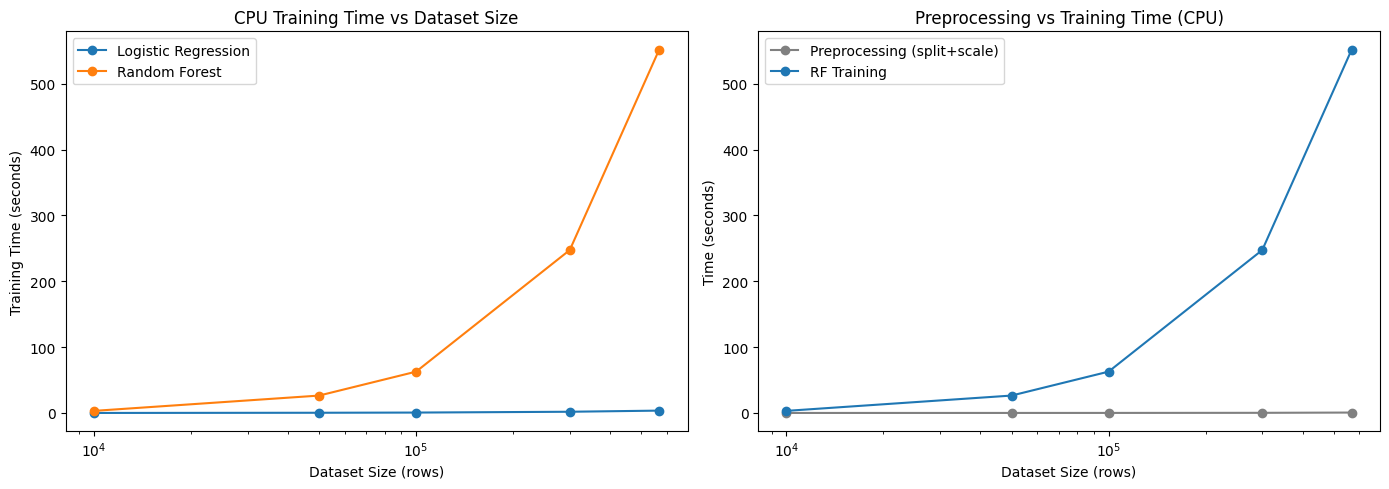

Done. Next step: run the equivalent GPU notebook, then combine cpu_scaling_results.csv and gpu_scaling_results.csv for the final CPU-vs-GPU crossover analysis and README.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(scaling_df['dataset_size'], scaling_df['lr_train_time'], marker='o', label='Logistic Regression')
axes[0].plot(scaling_df['dataset_size'], scaling_df['rf_train_time'], marker='o', label='Random Forest')
axes[0].set_xlabel('Dataset Size (rows)')
axes[0].set_ylabel('Training Time (seconds)')
axes[0].set_title('CPU Training Time vs Dataset Size')
axes[0].set_xscale('log')
axes[0].legend()

axes[1].plot(scaling_df['dataset_size'], scaling_df['preprocess_time_total'], marker='o', color='gray', label='Preprocessing (split+scale)')
axes[1].plot(scaling_df['dataset_size'], scaling_df['rf_train_time'], marker='o', label='RF Training')
axes[1].set_xlabel('Dataset Size (rows)')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Preprocessing vs Training Time (CPU)')
axes[1].set_xscale('log')
axes[1].legend()

plt.tight_layout()
plt.savefig('cpu_scaling_plot.png', dpi=150)
plt.show()

print("Done. Next step: run the equivalent GPU notebook, then combine "
      "cpu_scaling_results.csv and gpu_scaling_results.csv for the final "
      "CPU-vs-GPU crossover analysis and README.")